In [47]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np


In [48]:
# --- 0. 글로벌 환경 설정 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# --- 1. 데이터 증강용 콜레이트 및 배치 함수 정의 ---

def get_clip_box(image_a, image_b):
    image_size_x = image_a.shape[2]
    image_size_y = image_a.shape[1]
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()
    
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))
    
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)
    return x_min, y_min, x_max, y_max

def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    return torch.cat([top, middle, bottom], dim=1)

def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_shape, num_classes=120):
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_shape[2] * image_shape[1]
    ratio = mixed_area / total_area
    return (1 - ratio) * label_a + ratio * label_b

def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_image, mixed_label

def mixup(images, labels, batch_size, img_size, num_classes):
    mixed_imgs, mixed_labels = [], []
    for i in range(batch_size):
        j = torch.randint(0, batch_size, (1,)).item()
        m_img, m_lbl = mixup_2_images(images[i], images[j], labels[i], labels[j], num_classes)
        mixed_imgs.append(m_img)
        mixed_labels.append(m_lbl)
    return torch.stack(mixed_imgs), torch.stack(mixed_labels)

def cutmix(images, labels, prob, batch_size, img_size, num_classes):
    mixed_imgs, mixed_labels = [], []
    for i in range(batch_size):
        j = torch.randint(0, batch_size, (1,)).item()
        x_min, y_min, x_max, y_max = get_clip_box(images[i], images[j])
        mixed_imgs.append(mix_2_images(images[i], images[j], x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(labels[i], labels[j], x_min, y_min, x_max, y_max, images[i].shape, num_classes))
    return torch.stack(mixed_imgs), torch.stack(mixed_labels)

class AdvancedAugmentCollate:
    def __init__(self, aug_mode="no_aug", num_classes=120, p=0.5, img_size=224):
        self.aug_mode = aug_mode
        self.num_classes = num_classes
        self.p = p
        self.img_size = img_size

    def __call__(self, batch):
        images = torch.stack([item[0] for item in batch])
        labels = torch.tensor([item[1] for item in batch])
        current_batch_size = images.size(0)
        labels_onehot = F.one_hot(labels, num_classes=self.num_classes).float()

        if self.aug_mode in ["mixup", "cutmix"] and torch.rand(1).item() < self.p:
            if self.aug_mode == "mixup":
                return mixup(images, labels_onehot, current_batch_size, self.img_size, self.num_classes)
            elif self.aug_mode == "cutmix":
                return cutmix(images, labels_onehot, self.p, current_batch_size, self.img_size, self.num_classes)
        
        return images, labels_onehot


# --- 2. 전처리 및 데이터 로더 빌드 함수 ---

def get_transform(mode="no_aug"):
    if mode == "basic_aug":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])


# --- 3. 재조정된 핵심 학습 루프 함수 ---

def train(model, train_loader, test_loader, epochs, num_classes):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        # [TRAIN]
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels_onehot in train_loader:
            images, labels_onehot = images.to(device), labels_onehot.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_onehot)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            targets = torch.argmax(labels_onehot, dim=1)
            _, predicted = outputs.max(1)
            
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total
        history['train_loss'].append(train_loss)

        # [VALIDATION]
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels_onehot in test_loader:
                images, labels_onehot = images.to(device), labels_onehot.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels_onehot)
                val_loss += loss.item() * images.size(0)

                targets = torch.argmax(labels_onehot, dim=1)
                _, predicted = outputs.max(1)
                
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        epoch_val_loss = val_loss / total
        val_acc = 100. * correct / total
        
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return history

Using Device: cuda


Dataset Loaded. Total Images: 20580, Total Classes: 120

⚡ 현재 실험 진행 중 모드: NO_AUG
Epoch [1/10] -> Train Loss: 4.6199 | Val Loss: 4.3673 | Val Acc: 18.40% | Total Errors: 7003개
Epoch [2/10] -> Train Loss: 4.1318 | Val Loss: 3.7981 | Val Acc: 42.44% | Total Errors: 4940개
Epoch [3/10] -> Train Loss: 3.5826 | Val Loss: 3.1944 | Val Acc: 54.87% | Total Errors: 3873개
Epoch [4/10] -> Train Loss: 3.0412 | Val Loss: 2.6158 | Val Acc: 64.18% | Total Errors: 3074개
Epoch [5/10] -> Train Loss: 2.5661 | Val Loss: 2.1623 | Val Acc: 69.58% | Total Errors: 2611개
Epoch [6/10] -> Train Loss: 2.1711 | Val Loss: 1.8247 | Val Acc: 73.33% | Total Errors: 2289개
Epoch [7/10] -> Train Loss: 1.8617 | Val Loss: 1.5395 | Val Acc: 76.33% | Total Errors: 2031개
Epoch [8/10] -> Train Loss: 1.6132 | Val Loss: 1.3479 | Val Acc: 78.43% | Total Errors: 1851개
Epoch [9/10] -> Train Loss: 1.4244 | Val Loss: 1.1875 | Val Acc: 79.89% | Total Errors: 1726개
Epoch [10/10] -> Train Loss: 1.2798 | Val Loss: 1.0653 | Val Acc: 80.65% 

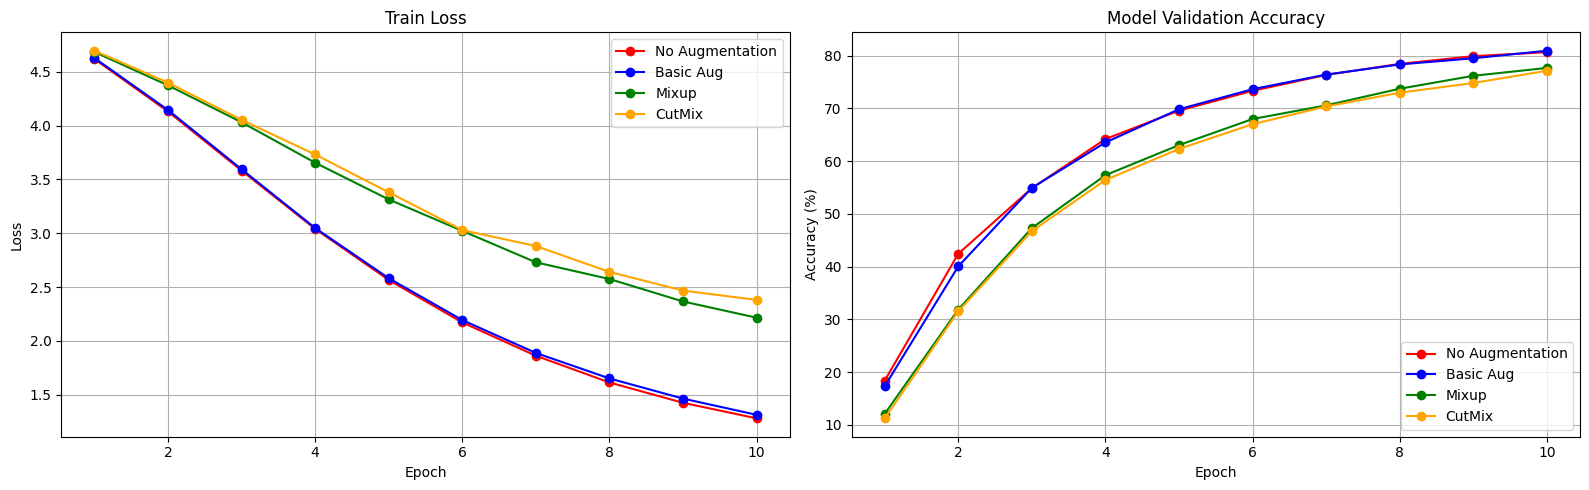

In [52]:

# 데이터셋 경로
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'data_augmentation')
dataset_dir = os.path.join(base_path, 'data', 'Images')


if __name__ == '__main__':
    # 기본 데이터셋 로드
    full_dataset = ImageFolder(root=dataset_dir, transform=get_transform("no_aug"))
    num_classes = len(full_dataset.classes)
    print(f"Dataset Loaded. Total Images: {len(full_dataset)}, Total Classes: {num_classes}")

    # 데이터셋 분할 분기
    train_size = int(0.583 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

    # 참조 격리를 위한 딥카피
    ds_train = copy.deepcopy(ds_train)
    ds_test = copy.deepcopy(ds_test)

    # 파라미터 세팅
    EPOCH = 10  # 효과 확인을 위해 필요시 20 이상으로 변경 가능
    BATCH_SIZE = 32
    modes = ["no_aug", "basic_aug", "mixup", "cutmix"]
    all_results = {}

    # 4가지 기법 교차 학습 수행
    for mode in modes:
        print(f"\n⚡ 현재 실험 진행 중 모드: {mode.upper()}")
        
        # 각 모드에 맞게 내부 transform 세팅 변환
        ds_train.dataset.transform = get_transform(mode)
        ds_test.dataset.transform = get_transform("no_aug")

        train_collate = AdvancedAugmentCollate(aug_mode=mode, num_classes=num_classes, p=0.5)
        test_collate = AdvancedAugmentCollate(aug_mode="no_aug", num_classes=num_classes)

        train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=train_collate)
        test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=test_collate)

        # 매 실험마다 신선한 모델 인스턴스 초기화
        resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

        # 학습 실행 및 기록 보관
        all_results[mode] = train(resnet50, train_loader, test_loader, epochs=EPOCH, num_classes=num_classes)


    # --- 5. 결과 다중 그래프 통합 시각화 ---
    epochs_range = range(1, EPOCH + 1)
    colors = {'no_aug': 'r', 'basic_aug': 'b', 'mixup': 'g', 'cutmix': 'orange'}
    labels = {'no_aug': 'No Augmentation', 'basic_aug': 'Basic Aug', 'mixup': 'Mixup', 'cutmix': 'CutMix'}

    plt.figure(figsize=(16, 5))

    # 그래프 1: Train Loss
    plt.subplot(1, 2, 1)
    for mode in modes:
        plt.plot(epochs_range, all_results[mode]['train_loss'], colors[mode], label=labels[mode], marker='o')
    plt.title('Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 그래프 2: Validation Accuracy
    plt.subplot(1, 2, 2)
    for mode in modes:
        plt.plot(epochs_range, all_results[mode]['val_accuracy'], colors[mode], label=labels[mode], marker='o')
    plt.title('Model Validation Accuracy')
    plt.ylabel('Accuracy (%)')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Dataset Loaded. Total Images: 20580, Total Classes: 120

⚡ 현재 실험 진행 중 모드: NO_AUG
Epoch [1/10] -> Train Loss: 4.6172 | Val Loss: 4.3438 | Val Acc: 20.71% | Total Errors: 6805개
Epoch [2/10] -> Train Loss: 4.1162 | Val Loss: 3.7663 | Val Acc: 44.94% | Total Errors: 4725개
Epoch [3/10] -> Train Loss: 3.5573 | Val Loss: 3.1463 | Val Acc: 57.00% | Total Errors: 3690개
Epoch [4/10] -> Train Loss: 3.0162 | Val Loss: 2.6107 | Val Acc: 64.59% | Total Errors: 3039개
Epoch [5/10] -> Train Loss: 2.5399 | Val Loss: 2.1432 | Val Acc: 70.45% | Total Errors: 2536개
Epoch [6/10] -> Train Loss: 2.1587 | Val Loss: 1.8009 | Val Acc: 73.89% | Total Errors: 2241개
Epoch [7/10] -> Train Loss: 1.8479 | Val Loss: 1.5109 | Val Acc: 76.81% | Total Errors: 1990개
Epoch [8/10] -> Train Loss: 1.6137 | Val Loss: 1.3297 | Val Acc: 78.35% | Total Errors: 1858개
Epoch [9/10] -> Train Loss: 1.4232 | Val Loss: 1.1766 | Val Acc: 80.03% | Total Errors: 1714개
Epoch [10/10] -> Train Loss: 1.2663 | Val Loss: 1.0643 | Val Acc: 80.75% 

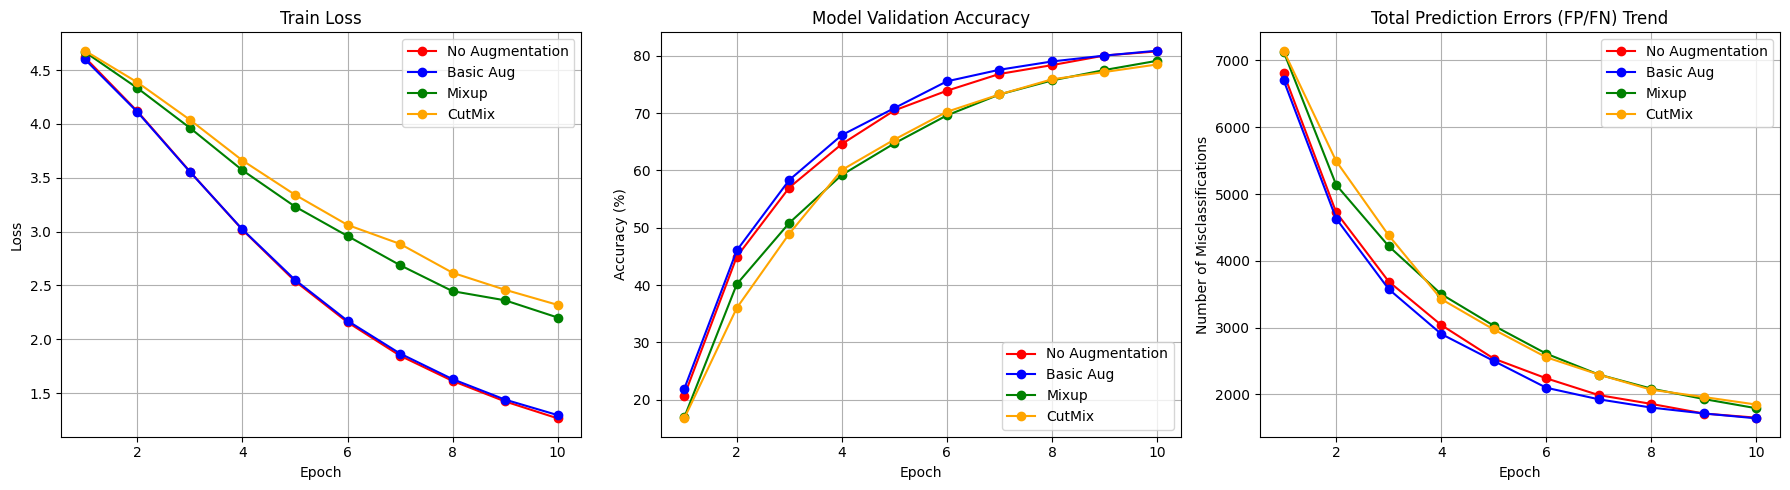

In [ ]:
# FP, FN 고려한 비교 실험

def train(model, train_loader, test_loader, epochs, num_classes):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    
    history = {
        'train_loss': [], 
        'val_loss': [], 
        'val_accuracy': [],
        'val_fp': [],  
        'val_fn': []   
    }

    for epoch in range(epochs):
        # ==========================================
        #                TRAIN STEP (복원됨)
        # ==========================================
        model.train()
        running_loss = 0.0
        train_total = 0

        for images, labels_onehot in train_loader:
            images, labels_onehot = images.to(device), labels_onehot.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_onehot)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            train_total += images.size(0)

        # 에폭별 Train Loss 계산 후 history에 반드시 추가 (이 부분이 비어있어서 에러가 났었습니다)
        epoch_train_loss = running_loss / train_total
        history['train_loss'].append(epoch_train_loss)
        
        # ==========================================
        #              VALIDATION STEP
        # ==========================================
        model.eval()
        val_loss = 0.0
        correct = 0
        val_total = 0
        
        total_fp = 0
        total_fn = 0
        
        with torch.no_grad():
            for images, labels_onehot in test_loader:
                images, labels_onehot = images.to(device), labels_onehot.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels_onehot)
                val_loss += loss.item() * images.size(0)

                targets = torch.argmax(labels_onehot, dim=1)
                _, predicted = outputs.max(1)
                
                val_total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

                # 다중 클래스 FP, FN 카운트 연산
                incorrect_mask = ~predicted.eq(targets)
                if incorrect_mask.sum() > 0:
                    total_fp += incorrect_mask.sum().item()
                    total_fn += incorrect_mask.sum().item()

        epoch_val_loss = val_loss / val_total
        val_acc = 100. * correct / val_total
        
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(val_acc)
        history['val_fp'].append(total_fp)
        history['val_fn'].append(total_fn)
        
        # total_fp 만 표현된 이유 (2개 레이블로 고정되어있어 예측 miss 발생 시 동일한 FP, FN 발생) fp = fn 상태임
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.2f}% | Total Errors: {total_fp}개")

    return history


# 데이터셋 경로
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'data_augmentation')
dataset_dir = os.path.join(base_path, 'data', 'Images')


if __name__ == '__main__':
    # (주의) get_transform 및 AdvancedAugmentCollate 정의 코드가 상단에 포함되어 있어야 합니다.
    full_dataset = ImageFolder(root=dataset_dir, transform=get_transform("no_aug"))
    num_classes = len(full_dataset.classes)
    print(f"Dataset Loaded. Total Images: {len(full_dataset)}, Total Classes: {num_classes}")

    # 데이터셋 분할
    train_size = int(0.583 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

    ds_train = copy.deepcopy(ds_train)
    ds_test = copy.deepcopy(ds_test)

    EPOCH = 10 
    BATCH_SIZE = 32
    modes = ["no_aug", "basic_aug", "mixup", "cutmix"]
    all_results = {}

    for mode in modes:
        print(f"\n⚡ 현재 실험 진행 중 모드: {mode.upper()}")
        ds_train.dataset.transform = get_transform(mode)
        ds_test.dataset.transform = get_transform("no_aug")

        train_collate = AdvancedAugmentCollate(aug_mode=mode, num_classes=num_classes, p=0.5)
        test_collate = AdvancedAugmentCollate(aug_mode="no_aug", num_classes=num_classes)

        train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=train_collate)
        test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=test_collate)

        resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

        all_results[mode] = train(resnet50, train_loader, test_loader, epochs=EPOCH, num_classes=num_classes)


    # --- [3. 결과 다중 그래프 통합 시각화 피드백 반영] ---
    epochs_range = range(1, EPOCH + 1)
    colors = {'no_aug': 'r', 'basic_aug': 'b', 'mixup': 'g', 'cutmix': 'orange'}
    labels = {'no_aug': 'No Augmentation', 'basic_aug': 'Basic Aug', 'mixup': 'Mixup', 'cutmix': 'CutMix'}

    # 3개 캔버스를 가로로 나열하기 위해 1x3 그리드로 통일 (plt.subplot 파라미터 수정)
    plt.figure(figsize=(18, 5))

    # 그래프 1: Train Loss
    plt.subplot(1, 3, 1)  # 1행 3열 중 1번째
    for mode in modes:
        plt.plot(epochs_range, all_results[mode]['train_loss'], colors[mode], label=labels[mode], marker='o')
    plt.title('Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 그래프 2: Validation Accuracy
    plt.subplot(1, 3, 2)  # 1행 3열 중 2번째
    for mode in modes:
        plt.plot(epochs_range, all_results[mode]['val_accuracy'], colors[mode], label=labels[mode], marker='o')
    plt.title('Model Validation Accuracy')
    plt.ylabel('Accuracy (%)')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 그래프 3: 에폭별 총 오탐(FP/FN) 개수 추이 비교
    plt.subplot(1, 3, 3)  # 1행 3열 중 3번째
    for mode in modes:
        plt.plot(epochs_range, all_results[mode]['val_fp'], colors[mode], label=labels[mode], marker='o')
    plt.title('Total Prediction Errors (FP/FN) Trend')
    plt.ylabel('Number of Misclassifications')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

프로젝트 진행 회고

---

data augmentation 방법인 cutmix 와 mixup에 대해 알아보고, 기존 augmentation 방법 대비 학습에 어떤 영향을 미치는지 ResNet50 모델을 대상으로 실험을 진행함

mixup은 두 이미지를 픽셀 단위로 투명도를 조절하듯 가중치(람다) 값에 따라 선형적으로 중첩시키는 방법임

cutmix는 이미지 A의 정해진 영역을 잘라내고(cut), 그 자리에 이미지 B를 붙여넣는(mix) 방법임 (cutout + mixup)

---

영향력 (cutmix 효과)

1. 기존 학습 방식

일반적인 분류 학습은 모델에게 100% 개 사진([1, 0])과 100% 고양이 사진([0, 1])만 주어진다. (하드레이블)

이 상태에서 모델은 두 클래스 사이의 경계선을 찾기 위해 주어지는데, 모델이 충분히 복잡하여 표현력이 강할 경우 개 데이터가 있는 영역과 고양이 데이터가 있는 영역을 가르는 경계선을 아주 엄격하게 나누게 된다. 

이 상태에서 문제가 발생하는데, 경계선 근처에서 아주 미세한 픽셀 변화만 생겨도 모델의 예측값이 널뛰게 된다. 이를 오버컨피던스(Overconfidence, 과잉확산)라고 한다. 

실제 데이터는 분류하려는 클래스 중 여러 클래스의 특징이 드러나는 데이터가 있을 수 있는데, 이 상태에서 모델이 중간지점 없이 극단적인 0 or 1로 예측하려하면서 과적합 문제가 발생하게 된다.



2. cutmix

반면 mixup, cutmix 등의 기법을 쓰기위해 한 이미지에 멀티 레이블을 적용하게 되면,

모델 입장에서는 개 영역에서 고양이 영역으로 이동할 때, 경계선에서 갑자기 정답이 바뀌는 게 아니라 "정답이 100% -> 80% -> ... -> 20% -> 0%로 천천히 부드럽게 감소하는 것을 학습하게 된다.

결과적으로 클래스를 가르는 날카로운 경계선이 사라지고, 두 클래스 사이에 "완충 지대(연속적인 확률 공간)"가 넓게 형성되는 것이다.


3. 정리

모델에게 이분법적 공간에서 부드럽고 연속적인 확률 공간(멀티 레이블)으로 확장하여 보여 줌으로써 

모델이 데이터의 정답을 단순한 '맞다/틀리다(Black or White)'의 이분법적 논리로 학습하는 것이 아니라, 클래스 간의 관계를 '얼마나 닮았는가(Gradient of Similarity)'의 

연속적인 스펙트럼으로 이해하게 만든다는 의미이다. 

(예를들어 [개: 98.7%, 고양이: 1.3%] 같은 답에서, [개: 55.0%, 고양이: 45.0%] 같은 완만하고 합리적인 확률을 출력할 수 있게 된다. 즉, 훈련되지 않고 애매한 사진을 넣어도 

삐빅! 무조건 고양이! 이딴소리하지 않고 충분히 헷갈려(?)하면서 예측해낸다)

이러한 성질 덕분에 훈련 데이터셋에 없는 낯선 데이터(Out-of-Distribution)나 노이즈가 들어와도 모델이 당황하지 않고 훨씬 안정적으로 예측(Robustness)할 수 있게 된다.

4. 단점

하지만, Mixup 방식이 분류(classification)에서 좋은 성능을 낼 수 있지만 자연스럽지 않은 데이터를 만들어내고, 

지역적으로 모호하고 비자연적이기 때문에 특히 지역화(Localization) 작업에서 모델을 혼란스럽게 만든다고 한다

---


레이블 형태 변경:

augmentation을 적용하지 않거나, 기본 augmatation 기법(resize, crop, flip 등) 외에 두 기법을 적용하려면

레이블이 반드시 원-핫 인코딩(One-Hot Encoding)된 소프트 레이블(Soft Label) 형태의 부동소수점(float) 벡터로 변경해야 한다. 

기존 클래스 [0.], [1.] 형태에서 원-핫 인코딩 형태로 변형해도 문제 없음

$$\text{Label} = [1.0, 0.0, 0.0] \quad (\text{Class 0: 100\%})$$

멀티 레이블 형태

$$\text{Label} = [0.6, 0.0, 0.4] \quad (\text{Class 0: 60\%, Class 2: 40\%})$$

--- 

모델에 Softmax를 구조적으로 명시하지 않아도 되는 이유:

파이토치의 손실 함수인 nn.CrossEntropyLoss 내부에서 자동으로 처리되기 때문


파이토치 CrossEntropyLoss 내부 구조:

nn.CrossEntropyLoss == nn.LogSoftmax + nn.NLLLoss (Negative Log Likelihood Loss)

---

결과 리뷰

mixup, cutmix를 적용한 케이스가 trainloss, validation accuracy, FP, FN 발생 수 모두 떨어지는 결과가 나옴
다만 강건성(robustness) 측면에서는 mixup, cutmix 적용한 케이스가 더 나은 것으로 판단됨

성능이 안좋은 이유는

1. train loss가 더 떨어지는 이유는 기존 0 or 1 문제보다 어려운 문제를 풀기 때문
2. 이전 학습에서 augmentation 비교를 위해 최소 20 epoch를 학습해야한다고 했는데, 현재 실험은 시간 관계상 10 epoch만 진행하였음. 
   아마도 데이터 특징 파악에 필요한 학습 수가 모자라서 그런 것이 아닐까 함(학습 정체기)


